# Data cleaning

### Import Libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Explaratory Data Analysis (EDA)

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check for distribution in numeric columns

In [45]:
# Drop passenger id
df1 = df.drop(columns = ['PassengerId'])

In [46]:
# view the numeric and categorical columns
numeric_cols = df1.select_dtypes(include = ['int64','float64']).columns
print(numeric_cols)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


### Visualise the distribution of numeric columns

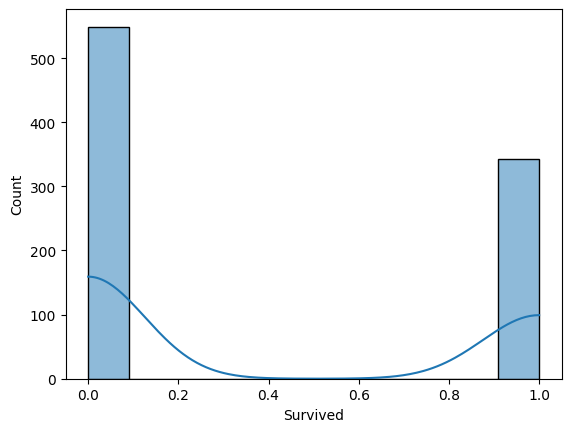

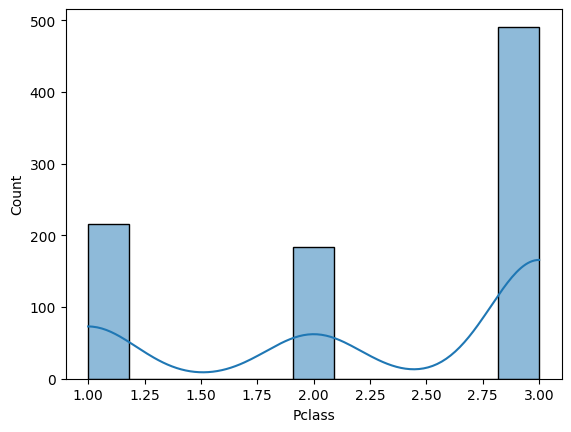

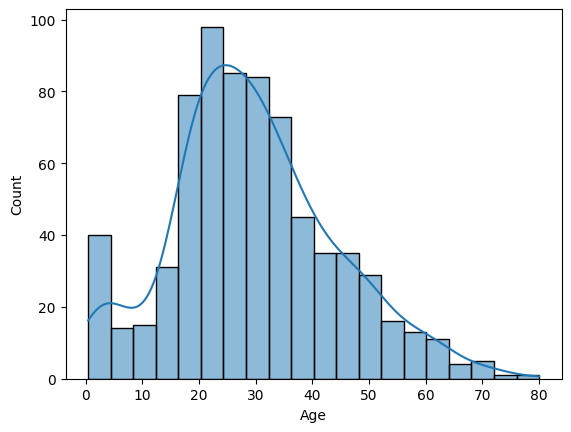

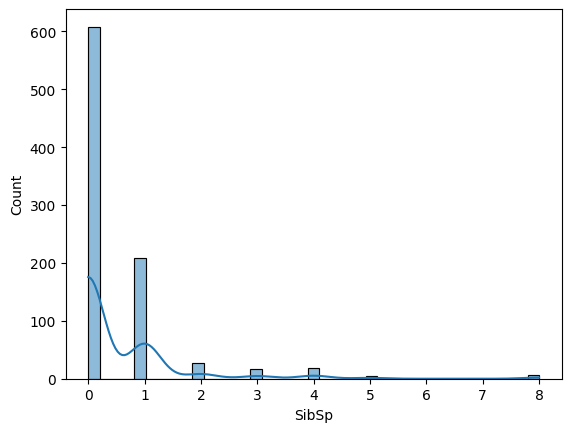

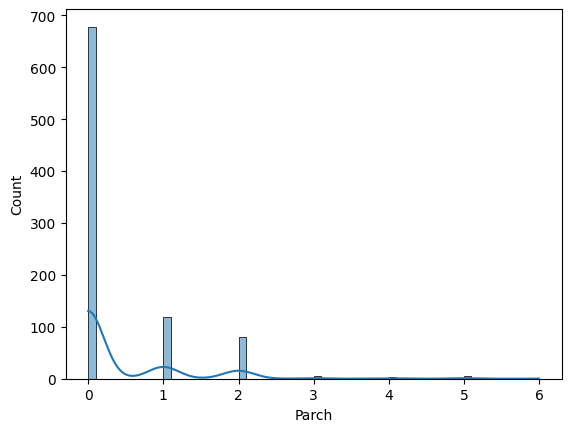

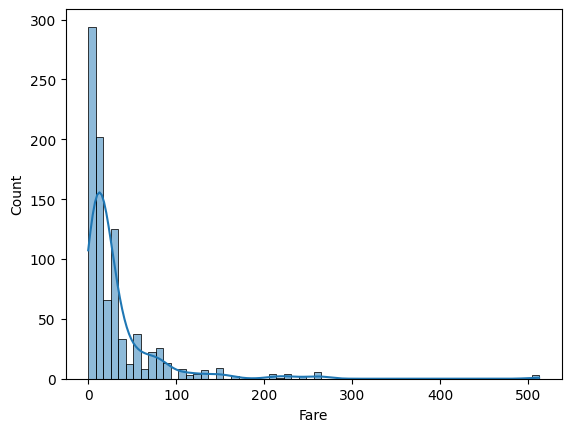

In [47]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df1[col], kde = True)
    plt.show()

### Target Variable Analysis

In [48]:
df1['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

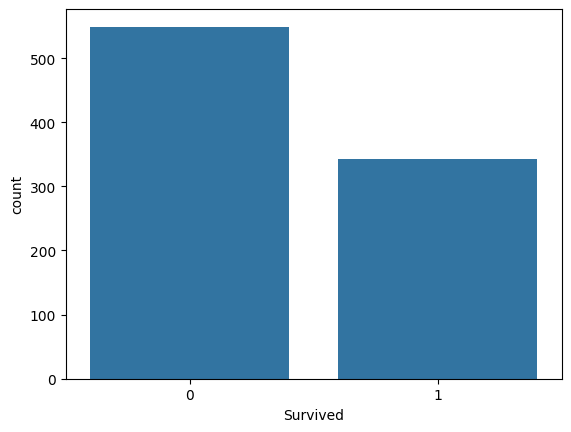

In [49]:
sns.countplot(x='Survived', data = df1)

### Survival vs Gender

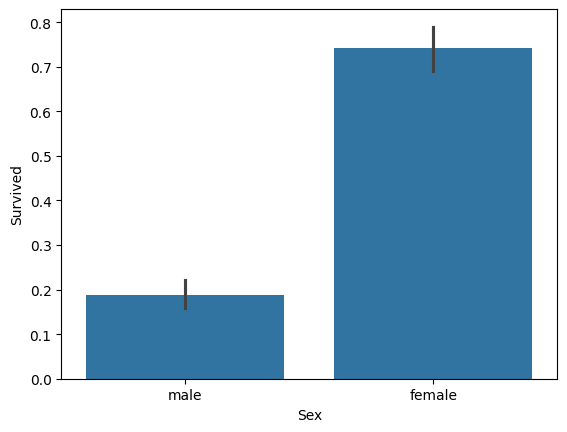

In [50]:
sns.barplot(x = 'Sex', y = 'Survived', data = df1)
plt.show()

### Survival vs Passenger class

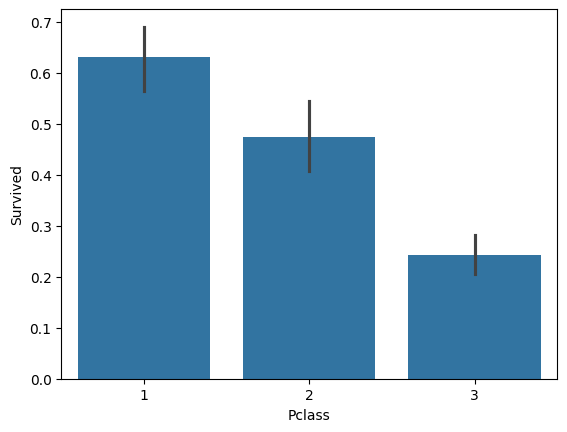

In [51]:
sns.barplot(x='Pclass', y = 'Survived', data = df1)
plt.show()

### Age vs Survival

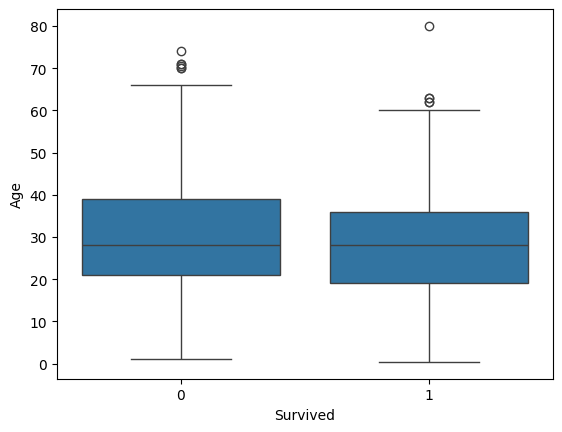

In [52]:
sns.boxplot(x = 'Survived', y = 'Age', data = df1)
plt.show()

### Correlation Analysis

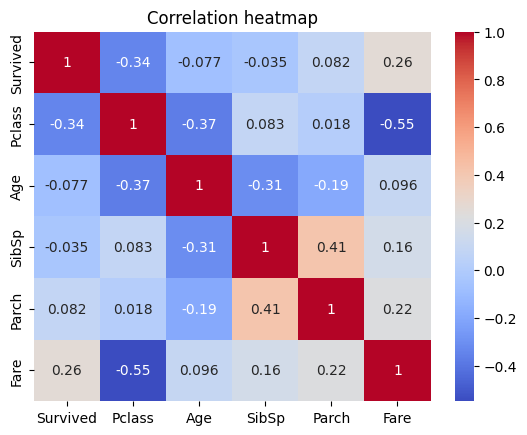

In [53]:
sns.heatmap(df1.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation heatmap')
plt.show()

# Data Cleaning

### Missing Value analysis

In [54]:
df1.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [55]:
missing_percent = (df1.isnull().sum() / len(df1)) * 100
missing_percent

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

### Visualise the missing values

In [56]:
import missingno as mnso

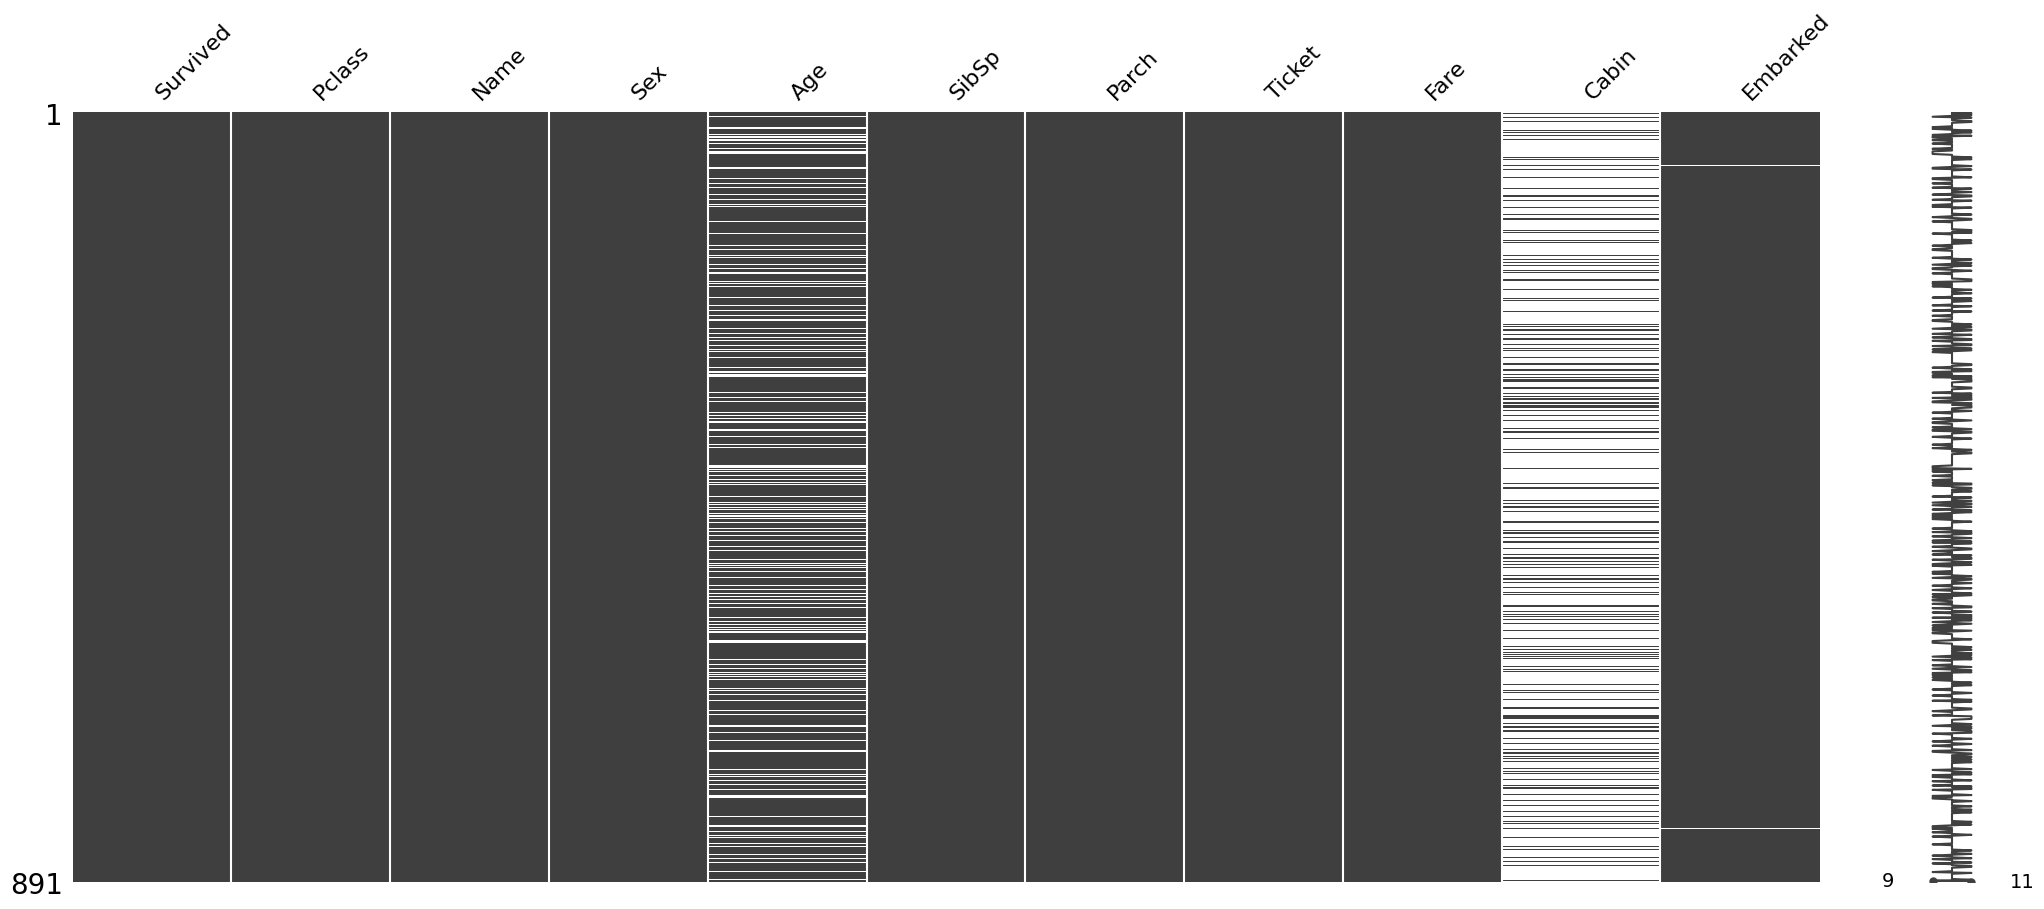

In [57]:
mnso.matrix(df1)
plt.show()

### Handle the missing values

In [58]:
# Drop the irrelevant columns
df2 = df1.drop(columns = ['Name','Ticket','Cabin'])
df2

# Age imputation
df2['Age'] = df2['Age'].fillna(df2['Age'].median())

# Embarked imputation
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

In [59]:
df2.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Detecting Outliers with boxplot

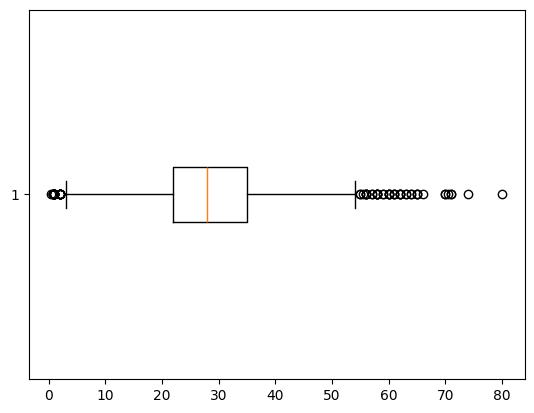

In [60]:
plt.boxplot(df2['Age'], vert = False)
plt.show()

### Calculate the outlier boundary

In [61]:
# Compute Q!, Q3 and IQR
Q1 = df2['Age'].quantile(0.25)
Q3 = df2['Age'].quantile(0.75)

IQR = Q3 - Q1

In [62]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [63]:
df2_no_outliers = df2[(df2['Age'] >= lower_bound) & (df2['Age'] <= upper_bound)]

In [64]:
print(f"Before: {len(df2)}")
print(f"After: {len(df2_no_outliers)}")

Before: 891
After: 825


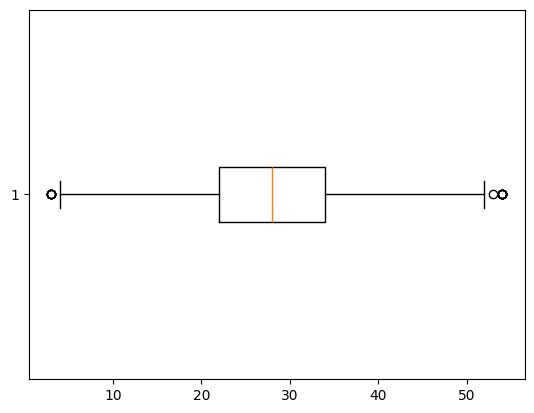

In [65]:
plt.boxplot(df2_no_outliers['Age'], vert = False)
plt.show()

In [66]:
df3 = df2_no_outliers

# Encoding

In [67]:
cat_col = [col for col in df3.columns if df3[col].dtype == 'str']
print(cat_col)

['Sex', 'Embarked']


In [68]:
# count the unique values in each categorical column
df3[cat_col].nunique()

Sex         2
Embarked    3
dtype: int64

In [69]:
# Use one hot encoding to convert categorical values to numeric format
df4 = pd.get_dummies(df3,columns = cat_col, drop_first = True) 
df4.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [71]:
bool_cols = ['Sex_male','Embarked_Q','Embarked_S']
df4[bool_cols] = df4[bool_cols].astype(int)

# Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df4[['Age', 'SibSp', 'Parch']] = std_scaler.fit_transform(df4[['Age', 'SibSp', 'Parch']])
df4[['Fare']] = rob_scaler.fit_transform(df4[['Fare']].values.reshape(-1, 1))